In [3]:
# ライブラリーのインポート
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# データの読み込み
data_trained = pd.read_csv('/kaggle/input/titanic/train.csv')
data_test = pd.read_csv('/kaggle/input/titanic/test.csv')
data_gender_submission = pd.read_csv('/kaggle/input/titanic/gender_submission.csv')

## 特徴量エンジニアリング
文字列を数値に置き換え
欠損値の扱い

In [18]:
# 教師データとテストデータ双方にエンジニアリングを行うため、結合
data_all = pd.concat([data_trained, data_test], sort = False) # 列の順番は変えずにただ結合してください

### 指針
1. 女性の方が生存率が高い → 男性と女性で特徴量を分けてみる
2. ParchとSibSpはどちらも家族構成の特徴量、また人数に応じて生存率が変わるので、合わせた特徴量を作ってみる
3. Ageは範囲が広いし、Missingも多い。平均で補完が不正確か。→ 中央値、あるいは平均±標準偏差の中からのランダム値で


In [19]:
# 各特徴量の欠損値の数を確認
# データの欠損は　isnull
# TestデータはSurvivedがないので欠損値扱い

data_all.isnull().sum()

# Null418件がテストデータの数を意味する

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

In [20]:
# Sexの値を男性と女性で分ける
# 同じ特徴量で傾向が大きく違うのであれば、特徴量を分けることで正確に反映し精度が上がるという考え方
# 列を追加
data_all['Sex_male'] = data_all['Sex'].replace(['female', 'male'], [0, 1])
data_all['Sex_female'] = data_all['Sex'].replace(['female', 'male'], [1, 0])
data_all['Sex'] = data_all['Sex'].replace(['female', 'male'], [1, 0])# 既存についても変換
data_all.head()

/tmp/ipykernel_17/1147175446.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_all['Sex_male'] = data_all['Sex'].replace(['female', 'male'], [0, 1])
/tmp/ipykernel_17/1147175446.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_all['Sex_female'] = data_all['Sex'].replace(['female', 'male'], [1, 0])
/tmp/ipykernel_17/1147175446.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_male,Sex_female
0,1,0.0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S,1,0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C,0,1
2,3,1.0,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S,0,1
4,5,0.0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S,1,0


<Axes: xlabel='Families', ylabel='count'>

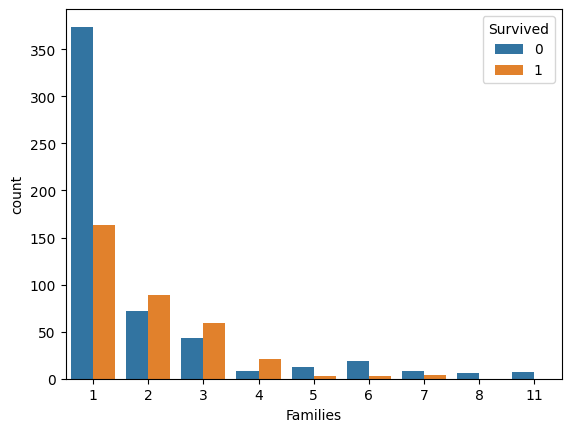

In [21]:
# ParchとSibSpはどちらも家族構成の特徴量、また人数に応じて生存率が変わるので、合わせた特徴量Familiesを作ってみる
data_all['Families'] = data_all['Parch'] + data_all['SibSp'] + 1
# 教師データの傾向を見るため、一時的にテストデータと分離
data_trained['Families'] = data_all['Families'][:len(data_trained)] # 教師データの件数分まで
data_test['Families'] = data_all['Families'][len(data_trained):] # 教師データの件数分以降

sns.countplot(x = 'Families', data = data_trained, hue = 'Survived')
# 単身者は0になるので、＋1で1人という情報を与える　
# Families で最後に＋1すると、単身者と、配偶者や子供や兄弟が一人いた人とが区別つかなくならない？）いっか、全てに＋1してるから、全体的に右によるだけで武ｂｂぷは変わらない


In [22]:
# 単身者は多すぎるので、別の特徴量として抜き出す
data_all['Alone'] = 0
data_all.loc[data_all['Families'] == 1, 'Alone'] = 1 # loc で行データの書き換え。Familiesが1（独り身）に対して、Aloneに1を入れる。
data_all.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_male,Sex_female,Families,Alone
0,1,0.0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S,1,0,2,0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C,0,1,2,0
2,3,1.0,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,1,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S,0,1,2,0
4,5,0.0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S,1,0,1,1


In [23]:
# Embarkedの欠損値を補完する、数値に置き換える
    # 2件でも欠損があればアルゴリズムは適応できないから
    # 本来なら欠損値を補完する方法を検討するが、今回は2件だし一番多いSで補完
data_all['Embarked'].fillna('S', inplace = True)
data_all['Embarked'].replace(['S', 'C', 'Q'], [0, 1, 2], inplace = True) # 変更後の結果をでーたふれ
data_all.head(900)

# One-Hotエンコーディング
    # Embarkedを1、2、3で置き換えると、その大きさに意味があるものとアルゴリズムに勘違いされてしまう場合がある。ので、データの数分、列数が増えるので、データサイズが大きくなる。
    # カテゴリ指定を予めできるものもあり、数値特有の大きさや順番を考慮しないものもある

/tmp/ipykernel_17/2239516266.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_all['Embarked'].fillna('S', inplace = True)
/tmp/ipykernel_17/2239516266.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_all['Embarked'].replace(['S', 'C', 'Q'], [0, 1, 2], inplace = True) # 変更後の結果をでーたふれ


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_male,Sex_female,Families,Alone
0,1,0.0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,0,1,0,2,0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,1,0,1,2,0
2,3,1.0,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,0,1,1,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,0,0,1,2,0
4,5,0.0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,896,NaN,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,12.2875,NaN,0,0,1,3,0
5,897,NaN,3,"Svensson, Mr. Johan Cervin",0,14.0,0,0,7538,9.2250,NaN,0,1,0,1,1
6,898,NaN,3,"Connolly, Miss. Kate",1,30.0,0,0,330972,7.6292,NaN,2,0,1,1,1
7,899,NaN,2,"Caldwell, Mr. Albert Francis",0,26.0,1,1,248738,29.0000,NaN,0,1,0,3,0


In [24]:
# Fareは平均で補完。
# Ageは、平均±標準偏差の中からのランダム値で補完
data_all['Fare'].fillna(np.mean(data_all['Fare']), inplace = True)

ave = data_all['Age'].mean()
std = data_all['Age'].std()
data_all['Age'].fillna(np.random.randint(ave - std, ave + std), inplace = True)
# 乱数なので再現性はないし、年齢および欠損値が正規分布に従っていると仮定しているが、中央値も手
# data_all['Age'].fillna(data_all['Age'].median(), inplace = True)
    
data_all.head()

/tmp/ipykernel_17/4048252845.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_all['Fare'].fillna(np.mean(data_all['Fare']), inplace = True)
/tmp/ipykernel_17/4048252845.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_male,Sex_female,Families,Alone
0,1,0.0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,0,1,0,2,0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,1,0,1,2,0
2,3,1.0,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,0,1,1,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,0,0,1,2,0
4,5,0.0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,0,1,0,1,1


In [25]:
# 影響のないあるいは少なそうな特徴量については一旦削除。
# drop 行または列で削除する関数。axis - 1で列方向
drop_colums = ['PassengerId', 'Name', 'Ticket', 'Cabin']
data_all.drop(drop_colums, axis = 1, inplace = True)
data_all.isnull().sum()
# まあこれでひとまず欠損値はなくなった
# SibSpやらParchは消していいのか？

Survived      418
Pclass          0
Sex             0
Age             0
SibSp           0
Parch           0
Fare            0
Embarked        0
Sex_male        0
Sex_female      0
Families        0
Alone           0
dtype: int64

In [26]:
# 結合したデータを、再度、教師データと、テストデータに分ける
# len関数は、行数を返してくれる。スライスで該当行を抜き出し。
# 先頭行から教師データの件数だけ抜き出すのと、その一個下のデータから
data_trained = data_all[:len(data_trained)]
data_test = data_all[len(data_trained):]

## モデル作成

### 検証
テストデータでの予測の前に、検証用データ（教示用のデータから作成）でモデルの精度を確かめとくこと。
過学習を防ぐ、またSubmitの回数制限があるので。

LightLgmは、勾配ブースティング手法で決定木を順々に作成しながら学習する

In [27]:
# アルゴリズムに投入。多くの場合別々に投入するのでそのために特徴量と目的変数を分離、x,yと頭文字をつけておく
y_data_trained = data_trained['Survived']
x_data_trained = data_trained.drop('Survived', axis = 1) # 説明変数を格納、dropで目的変数は削除。axis = 1は列を削除の意味
x_data_test = data_test.drop('Survived', axis = 1) # testデータにはSurvivedがなかったが、結合で列が発生したので消しておく。

In [28]:
# 用意。学習用データと検証用データに分割する
from sklearn.model_selection import train_test_split

# train_test_split関数で、説明・目的変数それぞれに学習用と検証用のデータ、4つを作る↓。
# test_sizeは検証用データの割合、学習用と検証用に、教師データを7:3で分ける。
# 乱数のシード。モデル改善なので、乱数を発生させるブレが出ないように
# stratify 学習用と検証用のデータで割合を保つ(Survivedの2値が、学習用とテスト用に偏って配置されると検証がうまくいかないので)


x_data_trained, x_data_valid, y_data_trained, y_data_valid = train_test_split(x_data_trained, y_data_trained, test_size=0.3, random_state=0, stratify=y_data_trained)

In [29]:
# optuna を利用する場合上の代わりに実行

import lightgbm as lgb

# LightGBMはカテゴリ変数を数値に変換しなくても処理してくれる。
categorical_features = ['Sex', 'Embarked', 'Pclass']

# ハイパラの調整（みんなのKaggle）
!pip install optuna

def objective(trial): # trial 特に意味はないが公式に準拠
    # ハイパラの探索範囲
    params = {
        'objective': 'binary',
        'max_bin': trial.suggest_int('max_bin', 200, 500), # デフォ255
        'learning_rate': 0.05, # デフォ0.1を小さめに
        'num_leaves': trial.suggest_int('num_leaves', 16, 128), # デフォ31を大きめに。一つの決定木における末端の最大数。同じくアルゴリズムの表現の幅を広げられる。
        'verbose': 0   # -1: 全て非表示, 0: 最小限, 1: 詳細
    }


# lgbのDataset関数で指定
# 上で指定したカテゴリリストを、ここで指定、いいように扱ってくれる
    lgb_data_train = lgb.Dataset(x_data_trained, y_data_trained, categorical_feature = categorical_features)
# 検証用データのreferenceに学習用データを指定
    lgb_data_eval = lgb.Dataset(x_data_valid, y_data_valid, reference = lgb_data_train, categorical_feature = categorical_features)

    verbose_eval = 10  # 学習の10回ごとに画面表示する(lgbのバージョンでエラーになるわ,と思ってたらいけたわ)
# モデルの訓練。train　学習用、検証用の順で引数に指定。下の3つはハイパーパラメータ（これ以上に色々ある）。学習の行い方を細かく、慎重に設定できる。
    model = lgb.train(params, lgb_data_train, valid_sets = [lgb_data_train, lgb_data_eval],
                            num_boost_round = 500, # 学習を何回繰り返すか？LightLgmは、勾配ブースティング手法で決定木を順々に作成しながら学習する、これを1000回
                            callbacks = [lgb.early_stopping(stopping_rounds=10,
                                        verbose = True),
                                         lgb.log_evaluation(verbose_eval)]
                  # early_stopping_rounds = 10) (使えない。)# 大事。精度が上がりやすいが過学習が起こりやすいので、roundの処理を止めてあげる。誤差がこれ以上小さくならない、タイミングで、10回だけは様子見で学習してから、　変わらないならストップする
                 )
    from sklearn.metrics import log_loss

    y_valid = model.predict(x_data_valid, num_iteration=model.best_iteration)  # 訓練済みのモデルを使用
    score = log_loss(y_data_valid, y_valid)  # 二値の交差エントロピー誤差
    return score

In [30]:
# Optunaを使い、ハイパーパラメータを最適化します。
import optuna
study = optuna.create_study(sampler=optuna.samplers.RandomSampler())
study.optimize(objective, n_trials=30)

# ベストなハイパーパラメータを表示します。
print(study.best_params)

[I 2026-02-26 08:02:14,691] A new study created in memory with name: no-name-3f60c033-9c9c-4de3-8959-fdfd6ca6fc78
[I 2026-02-26 08:02:14,805] Trial 0 finished with value: 0.430920476414255 and parameters: {'max_bin': 380, 'num_leaves': 104}. Best is trial 0 with value: 0.430920476414255.
[I 2026-02-26 08:02:14,871] Trial 1 finished with value: 0.430920476414255 and parameters: {'max_bin': 351, 'num_leaves': 80}. Best is trial 0 with value: 0.430920476414255.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 10 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[10]	training's binary_logloss: 0.504523	valid_1's binary_logloss: 0.53034
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

[I 2026-02-26 08:02:14,956] Trial 2 finished with value: 0.430920476414255 and parameters: {'max_bin': 310, 'num_leaves': 59}. Best is trial 0 with value: 0.430920476414255.
[I 2026-02-26 08:02:15,020] Trial 3 finished with value: 0.430920476414255 and parameters: {'max_bin': 271, 'num_leaves': 128}. Best is trial 0 with value: 0.430920476414255.
[I 2026-02-26 08:02:15,079] Trial 4 finished with value: 0.430920476414255 and parameters: {'max_bin': 392, 'num_leaves': 56}. Best is trial 0 with value: 0.430920476414255.
[I 2026-02-26 08:02:15,142] Trial 5 finished with value: 0.430920476414255 and parameters: {'max_bin': 387, 'num_leaves': 81}. Best is trial 0 with value: 0.430920476414255.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 10 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[10]	training's binary_logloss: 0.504523	valid_1's binary_logloss: 0.53034
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

[I 2026-02-26 08:02:15,205] Trial 6 finished with value: 0.430920476414255 and parameters: {'max_bin': 367, 'num_leaves': 54}. Best is trial 0 with value: 0.430920476414255.
[I 2026-02-26 08:02:15,266] Trial 7 finished with value: 0.430920476414255 and parameters: {'max_bin': 473, 'num_leaves': 105}. Best is trial 0 with value: 0.430920476414255.
[I 2026-02-26 08:02:15,336] Trial 8 finished with value: 0.4254958015745423 and parameters: {'max_bin': 413, 'num_leaves': 19}. Best is trial 8 with value: 0.4254958015745423.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[20]	training's binary_logloss: 0.421158	valid_1's binary_logloss: 0.476378
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

[I 2026-02-26 08:02:16,245] Trial 23 finished with value: 0.430920476414255 and parameters: {'max_bin': 464, 'num_leaves': 96}. Best is trial 8 with value: 0.4254958015745423.
[I 2026-02-26 08:02:16,303] Trial 24 finished with value: 0.430920476414255 and parameters: {'max_bin': 368, 'num_leaves': 122}. Best is trial 8 with value: 0.4254958015745423.
[I 2026-02-26 08:02:16,361] Trial 25 finished with value: 0.430920476414255 and parameters: {'max_bin': 415, 'num_leaves': 106}. Best is trial 8 with value: 0.4254958015745423.
[I 2026-02-26 08:02:16,420] Trial 26 finished with value: 0.430920476414255 and parameters: {'max_bin': 389, 'num_leaves': 55}. Best is trial 8 with value: 0.4254958015745423.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[40]	training's binary_logloss: 0.341645	valid_1's binary_logloss: 0.431945
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

[I 2026-02-26 08:02:16,480] Trial 27 finished with value: 0.430920476414255 and parameters: {'max_bin': 316, 'num_leaves': 91}. Best is trial 8 with value: 0.4254958015745423.
[I 2026-02-26 08:02:16,536] Trial 28 finished with value: 0.430920476414255 and parameters: {'max_bin': 270, 'num_leaves': 116}. Best is trial 8 with value: 0.4254958015745423.
[I 2026-02-26 08:02:16,608] Trial 29 finished with value: 0.4283827294300661 and parameters: {'max_bin': 210, 'num_leaves': 74}. Best is trial 8 with value: 0.4254958015745423.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 10 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[10]	training's binary_logloss: 0.504523	valid_1's binary_logloss: 0.53034
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

In [31]:
# ベストなハイパーパラメータを使って予測を行います。
params = {
        'objective': 'binary',
        'max_bin': study.best_params['max_bin'], # デフォ255
        'learning_rate': 0.05, # デフォ0.1を小さめに
        'num_leaves': study.best_params['num_leaves'], # デフォ31を大きめに。一つの決定木における末端の最大数。同じくアルゴリズムの表現の幅を広げられる。
        'verbose': 0   # -1: 全て非表示, 0: 最小限, 1: 詳細
    }


# lgbのDataset関数で指定
# 上で指定したカテゴリリストを、ここで指定、いいように扱ってくれる
lgb_data_train = lgb.Dataset(x_data_trained, y_data_trained, categorical_feature = categorical_features)
# 検証用データのreferenceに学習用データを指定
lgb_data_eval = lgb.Dataset(x_data_valid, y_data_valid, reference = lgb_data_train, categorical_feature = categorical_features)

verbose_eval = 10  # 学習の10回ごとに画面表示する(lgbのバージョンでエラーになるわ,と思ってたらいけたわ)
# モデルの訓練。train　学習用、検証用の順で引数に指定。下の3つはハイパーパラメータ（これ以上に色々ある）。学習の行い方を細かく、慎重に設定できる。
model = lgb.train(params, lgb_data_train, valid_sets = [lgb_data_train, lgb_data_eval],
                            num_boost_round = 500, # 学習を何回繰り返すか？LightLgmは、勾配ブースティング手法で決定木を順々に作成しながら学習する、これを1000回
                            callbacks = [lgb.early_stopping(stopping_rounds=10,
                                        verbose = True),
                                         lgb.log_evaluation(verbose_eval)]
                  # early_stopping_rounds = 10) (使えない。)# 大事。精度が上がりやすいが過学習が起こりやすいので、roundの処理を止めてあげる。誤差がこれ以上小さくならない、タイミングで、10回だけは様子見で学習してから、　変わらないならストップする
                 )

Training until validation scores don't improve for 10 rounds
[10]	training's binary_logloss: 0.505186	valid_1's binary_logloss: 0.529773
[20]	training's binary_logloss: 0.422641	valid_1's binary_logloss: 0.476568
[30]	training's binary_logloss: 0.373936	valid_1's binary_logloss: 0.44543
[40]	training's binary_logloss: 0.34478	valid_1's binary_logloss: 0.434124
[50]	training's binary_logloss: 0.324193	valid_1's binary_logloss: 0.43156
[60]	training's binary_logloss: 0.30638	valid_1's binary_logloss: 0.427468
[70]	training's binary_logloss: 0.290313	valid_1's binary_logloss: 0.426096
Early stopping, best iteration is:
[69]	training's binary_logloss: 0.29171	valid_1's binary_logloss: 0.425496


In [32]:
y_data_pred = model.predict(x_data_test, num_iteration = model.best_iteration)

# num_iteration 最適な回数（25回だった）でテストデータを予測（？であってるかな）
y_data_pred[:5]

array([0.02085862, 0.42370574, 0.11346762, 0.0692753 , 0.38794444])

In [33]:
# 0.5を上回れば1と予測したとみなす
y_data_pred = (y_data_pred > 0.5).astype(int) # astypeで小数型から整数型
y_data_pred[:5]

array([0, 0, 0, 0, 0])

## Submit

In [34]:
# 予測結果をSubmit用のCSVファイルとして作成
submit = data_gender_submission # 冒頭で作った変数。提出用CSVのこと。めんどいのでsubmitとする。
submit['Survived'] = list(map(int, y_data_pred)) 
# map 指定した要素に対して、適用したい関数（int）を適用できる関数。予測結果を整数型にして提出フォーマットに合わせるため。
# リストで提出用ファイルに.
submit.to_csv('Lightgbm_tuned_submit.csv', index = False) # 出力ファイル名,index番号は出力しない


# データ量が多くないので、パラメータいじって丁寧にしすぎて過学習気味になっているか？
# 特徴量エンジニアリングん方が遥かに重要！！